In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
#torchvision helps in scaling and normalizing the image before passing it to CNN
from torchvision.datasets import CIFAR10


In [8]:
# Datsets & DataLoaders

from torch.utils.data import DataLoader
import torchvision.transforms as transforms
#this transforms is torch vision utility which helps to perform operations on image

# image => scale (0,1) => normalize => (-1,1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = CIFAR10(root = "./data", train =True, download=True, transform=transform)

testset = CIFAR10(root = "./data", train =False, download=True, transform=transform)

100%|██████████| 170M/170M [00:20<00:00, 8.34MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [9]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [10]:
trainloader = DataLoader(trainset, batch_size=64 ,shuffle=True)
testloader = DataLoader(testset, batch_size=64)

Build CNN

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2 ,2), #kernel size=2, stride value=2

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2 ,2), #kernel size=2, stride value=2

            nn.Conv2d(64,128,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2 ,2) #kernel size=2, stride value=2
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0),-1) # flatteing
        x = self.fc_layers(x)

        return x

In [12]:
model = CNN()

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

Training the CNN

In [14]:
epochs = 10
for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad() 
        output = model.forward(images) #forward propagaration
        loss = criterion(output, labels) # loss fix
        loss.backward() #backward propagation
        optimizer.step() #update params

        epoch_training_loss += loss.item()
    
    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")     

epoch=1/10 & loss=1.3670987301622815
epoch=2/10 & loss=0.9270492195320861
epoch=3/10 & loss=0.7351386734972829
epoch=4/10 & loss=0.6071639549930382
epoch=5/10 & loss=0.49453946404978444
epoch=6/10 & loss=0.4006324200640859
epoch=7/10 & loss=0.3108032046509978
epoch=8/10 & loss=0.23756531456394878
epoch=9/10 & loss=0.17809266714221986
epoch=10/10 & loss=0.13823931493684458


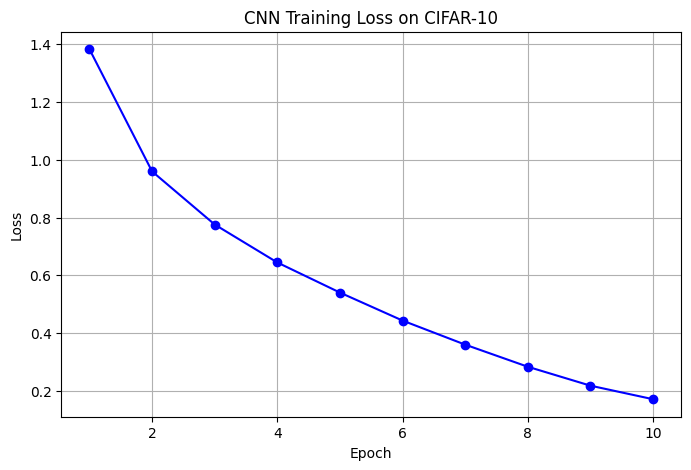

In [15]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

train_losses = [
    1.382292341088395,
    0.9594956599842862,
    0.7756994644470532,
    0.6443971023154076,
    0.5402550289926626,
    0.4433698146353902,
    0.36010991452295155,
    0.2836045522690582,
    0.21815500921472106,
    0.17129959188439808
]

epochs = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", color="blue")
plt.title("CNN Training Loss on CIFAR-10")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig("images/training_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
# Evaluate our CNN

correct_labels = 0
total_labels =  0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _,predicted = torch.max(outputs,1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy ={correct_labels/total_labels * 100}")


accuracy =75.56


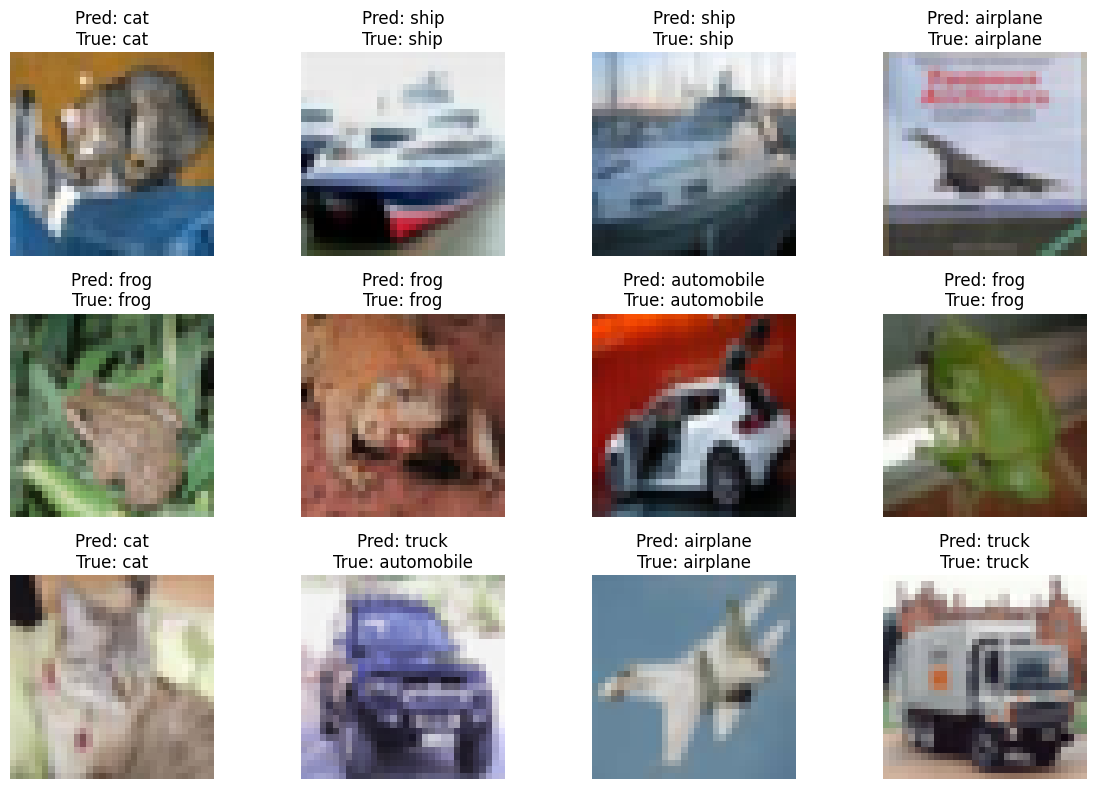

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def imshow(img):
    img = img / 2 + 0.5
    np_img = img.numpy()
    return np.transpose(np_img, (1, 2, 0))

model.eval()

images, labels = next(iter(testloader))

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(imshow(images[i]))
    plt.title(f"Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("images/sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()
